# Objectif du notebook 

Date de création : 13/01/2026

L'objectif est de d'estimer le temps d'arrivée de chacun des signaux émis par la source. 

In [2]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import butter, lfilter

In [3]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

In [4]:
sys.path.append(project_root)
from publication.publication_figure import PubFigure, color


# Chargement des données utiles 

In [5]:
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Exemple avec un unique signal

## Chargement des informations relatives aux émissions 

In [6]:
fpath = os.path.join(data_folder, "source_emissions_processed_dtypes.csv")
df_dtypes= pd.read_csv(fpath, index_col=0).to_dict()["dtype"]

fpath = os.path.join(data_folder, "source_emissions_processed.csv")
col_to_parse_date = [key for key in df_dtypes.keys() if "datetime" in df_dtypes[key]]
# Remove these columns from df_dtypes as they will be parsed as dates
for col in col_to_parse_date:
    df_dtypes.pop(col)
# Load dataframe with specified dtypes and parse dates
df = pd.read_csv(fpath, dtype=df_dtypes, parse_dates=col_to_parse_date)

In [7]:
df.dtypes       # Here can verifiy that the dtypes are correctly assigned

Emission datetime              datetime64[ns]
Sequence_id                            object
Point                                  object
Source                                 object
Longueur filée (m)                     object
Hydro distance (m)                    float32
Signal                                 object
Frequency min (Hz)                    float32
Frequency max (Hz)                    float32
Duration (s)                          float32
Nrepeat                                 int32
Trepeat (s)                           float32
Vc carte (V)                          float32
Gain ampli                            float32
File                                   object
File start datetime            datetime64[ns]
Start sample                           object
Emission latitude GPS                 float64
Emission longitude GPS                float64
Emission E GPS                        float64
Emission N GPS                        float64
Emission U GPS                    

### Remarque : calcul de la position de la source 
Le dataframe df contient la position de l'antenne GPS estimée à l'instant de l'émission. En pratique, la source n'est pas colocalisée avec l'antenne et il faut théoriquement prendre en compte ce bras de levier.

Au moins dans le cas des émissions en statique on peut considérer, au regard de l'incertitude sur le positionnement de l'antenne GPS à l'instant émission (incertitude GPS standard + interpolation linéaire entre deux points GPS), que la source est colocalisée avec l'antenne GPS. 

Dans le cas dynamique la longueur filée est importante $\approx$ 15/20 m. Dans ce cas, il peut être plus difficile de négliger le bras de levier entre l'antenne GPS et la source immergée. La longueur filée est connue ainsi que l'immersion de la source (capteur de pression sur la source), on peut ainsi calculer la distance (à la surface) de l'antenne GPS à la source (dans l'axe du navire). Néanmoins, afin de transformer ce bras de levier dans le repère du navire en un offset sur la position dans le repère ENU il est nécessaire de connaitre le cap du navire dans le repère ENU. 

Pour ce faire, on peut estimer le cap du navire à partir de l'estimation du vecteur vitesse du navire à l'instant d'émission : 

$$ V_{gps}^{(ENU)} = [V_e, V_n]^T$$

$$V_e = \frac{E_{gps}(t_{n+1}) - E_{gps}(t_n)}{\Delta t}$$
et 
$$V_n = \frac{N_{gps}(t_{n+1}) - N_{gps}(t_n)}{\Delta t}$$

où $t_n$ et $t_{n+1}$ sont les instants précèdent et successif à l'instant d'émission dans la série temporelle des positions GPS. 

Le cap du navire dans le repère ENU est alors donné par : 

$$\alpha = \arctan{\frac{V_e}{V_n}}$$

La position dans le repère du navire est (hypothèse source dans l'axe du navire):

$$X_s^{(Navire)} = [0, -bdl]^T$$

où $bdl$ est la distance, selon l'axe $y_{navire}$, de l'origine du repère du navire (position de l'antenne GPS) au projeté orthogonal de la position de la source sur la surface. 

Finalement :

$$X_s^{(ENU)} = X_{GPS}^{(ENU)} + R_{\text{Nav to ENU}} X_s^{(Navire)}$$

avec 
$$ R_{\text{Nav to ENU}} = \begin{bmatrix} \cos{\alpha} & \sin{\alpha} \\ -\sin{\alpha} & \cos{\alpha} \end{bmatrix}$$

Proche des OBS la correction pourrait avoir un impacte significatif. 

In [8]:
# Function to compute the real position of the source considering the offset 
# e_gps_poulie = 



In [9]:
def get_wav_file_for_emission(emission_datetime, start_datetime_arr, wav_start_times):
    # Compute time differences between emission and wav start times
    dt = emission_datetime - start_datetime_arr
    # Keep only positive time differences (we are only looking for wav files that start before the emission)
    dt_is_positive = dt >= pd.Timedelta(0)
    # Find closest
    wav_start_datetime = start_datetime_arr[dt_is_positive][-1]
    # Get corresponding wav file path
    wav_fpath = wav_start_times[wav_start_datetime]
    return wav_fpath, wav_start_datetime

In [10]:
def get_tr_apriori(emission_pos, wav_start_datetime, emission_datetime, obs_id):
    # Extract emission position
    e_emission, n_emission, u_emission = emission_pos

    # Get receiver apriori position
    e_obs = ds_gps.attrs[f"obs{obs_id}_e_apriori"]
    n_obs = ds_gps.attrs[f"obs{obs_id}_n_apriori"]
    u_obs = ds_gps.attrs[f"obs{obs_id}_u_apriori"]

    # Derive apriori propagation distance
    prop_range = np.sqrt(
        (e_emission - e_obs) ** 2
        + (n_emission - n_obs) ** 2
        + (u_emission - u_obs) ** 2
    )

    # Derive apriori propagation time
    c0 = 1500
    prop_time = prop_range / c0

    # Deduce apriori reception time
    reception_datetime = emission_datetime + pd.Timedelta(prop_time, "s")

    # Derive reception time from wav start
    tr = reception_datetime - wav_start_datetime
    # Convert to seconds
    tr = tr.total_seconds()

    return reception_datetime, tr, prop_time

In [11]:
import scipy.signal as sp

def apply_match_filter(signal, fs, f0, f1, T):
    """
    Apply match filtering to a chirp signal.
    
    Parameters:
    signal : ndarray
        The received signal to be processed.
    fs : float
        Sampling frequency in Hz.
    f0 : float
        Start frequency of the chirp in Hz.
    f1 : float
        End frequency of the chirp in Hz.
    T : float
        Duration of the chirp in seconds.
        
    Returns:
    compressed_signal : ndarray
        The pulse-compressed signal.
    """
    # Generate the reference chirp signal
    t = np.arange(0, T, 1/fs)
    reference_chirp = sp.chirp(t, f0=f0, f1=f1, t1=T, method="linear")

    # Perform matched filtering (cross-correlation)
    sig_mf = np.correlate(signal, reference_chirp, mode='same')
    lags = (
        sp.correlation_lags(t.size, t.size, mode="same") * 1 / fs
    )
    return lags, sig_mf

In [12]:
# def

In [13]:
def plot_arrivals_detection(
    t_win,
    signal_win,
    sig_mf,
    t_arrivals,
    peaks_idx,
    peak_times,
    sequence_info,
    signal_params,
    first_emission_reception_datetime=None,
    last_emission_reception_datetime=None,
    plot_last_first=False,
    t_hydro_source_offset=31,
    save=False,
    img_root=None, 
    fs=2000,
    nperseg=64,
    noverlap=32,
    first_emission_in_sequence_datetime=None,
    last_emission_in_sequence_datetime=None,
    verbose=False,
    plot_zoom=False,
):

    if verbose:
        print("Plotting arrivals...")

    if img_root is None: 
        img_root = os.path.join(
                    img_folder, "reception", "arrivals_detection"
                )

    # Unwrap sequence information
    seq_id = sequence_info.get("seq_id", None)
    obs_id = sequence_info.get("obs_id", None)
    vc_carte = sequence_info.get("vc_carte", None)
    signal_type = sequence_info.get("signal_type", None)
    emission_type = sequence_info.get("emission_type", None)

    # Normalize signal for better visualization
    signal_win = signal_win / np.max(np.abs(signal_win))

    # Compute spectrogram for visualization
    ff, tt, Sxx = sp.stft(
        signal_win,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",
    )
    tt_datetime = pd.date_range(
        t_win[0], t_win[0] + pd.Timedelta(tt[-1], "s"), freq=f"{tt[1]-tt[0]}s", inclusive="both"
    )

    fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    # Plot raw signal
    axs[0].plot(t_win, signal_win, color="k")
    axs[0].set_ylim([-1, 1])
    # Plot matched filtered signal
    axs[1].plot(t_win, sig_mf, color="k")
    axs[1].set_ylim([-1, 1])

    # Add detected peaks
    if len(peaks_idx) > 0:
        axs[1].scatter(
            peak_times,
            sig_mf[peaks_idx],
            marker="o",
            color="r",
            label=r"$t_{\text{peak}}$",
            s=5,
            zorder=10,
        )

    axs[0].set_ylabel("s")
    axs[1].set_ylabel(r"$s_{mf}$")

    im = axs[2].pcolormesh(tt_datetime, ff, 10 * np.log10(np.abs(Sxx)), cmap="jet")
    # fig.colorbar(im, cax=axs[2], label=r"Pa$^2$ / Hz in dB")
    axs[2].set_ylabel("Fréquence [Hz]")

    # Add arrivals
    if len(t_arrivals) > 0:
        # Plot arrows for arrivals
        for iarr, t_arrival in enumerate(t_arrivals):
            axs[0].annotate(
                f"{iarr}",
                xy=(t_arrival, 0.5),
                xytext=(t_arrival, 0.9),
                arrowprops=dict(arrowstyle="->", color="red"),
                horizontalalignment="center",
                verticalalignment="center",
            )
            axs[2].annotate(
                f"{iarr}",
                xy=(t_arrival, np.max(ff) * 0.75),
                xytext=(t_arrival, np.max(ff) * 0.95),
                arrowprops=dict(arrowstyle="->", color="black"),
                horizontalalignment="center",
                verticalalignment="center",
            )

    if plot_last_first:
        for i in range(len(axs)):
            if first_emission_reception_datetime is None or last_emission_reception_datetime is None:
                raise ValueError("first_emission_reception_datetime and last_emission_reception_datetime must be provided when plot_last_first is True.")
            
            axs[i].axvline(
                first_emission_reception_datetime,
                color="g",
                linestyle="--",
                label=r"$T_{\text{reception}}(\text{first})$",
            )
            axs[i].axvline(
                last_emission_reception_datetime,
                color="b",
                linestyle="--",
                label=r"$T_{\text{reception}}(\text{last})$",
            )
            if first_emission_in_sequence_datetime is not None:
                axs[i].axvline(
                    first_emission_in_sequence_datetime,
                    color="red",
                    linestyle="--",
                    label=r"$T_{\text{emission}}(\text{first})$",
                )
            if last_emission_in_sequence_datetime is not None:
                axs[i].axvline(last_emission_in_sequence_datetime, color="red", linestyle="--", label=r"$T_{\text{emission}}(\text{last})$")

        for i in range(len(axs)):
            axs[i].axvline(
                first_emission_reception_datetime
                + pd.Timedelta(t_hydro_source_offset, "s"),
                color="g",
                linestyle="-",
                label=r"$T_{\text{reception}}(\text{first}) + \tau_{H_{\text{source}}}$",
            )

            axs[i].axvline(
                last_emission_reception_datetime + pd.Timedelta(t_hydro_source_offset, "s"),
                color="b",
                linestyle="-",
                label=r"$T_{\text{reception}}(\text{last}) + \tau_{H_{\text{source}}}$",
            )
            if first_emission_in_sequence_datetime is not None:
                axs[i].axvline(
                    first_emission_in_sequence_datetime
                    + pd.Timedelta(t_hydro_source_offset, "s"),
                    color="red",
                    linestyle="-",
                    label=r"$T_{\text{emission}}(\text{first}) + \tau_{H_{\text{source}}}$",
                )
            if last_emission_in_sequence_datetime is not None:
                axs[i].axvline(
                    last_emission_in_sequence_datetime + pd.Timedelta(t_hydro_source_offset, "s"),
                    color="red",
                    linestyle="-",
                    label=r"$T_{\text{emission}}(\text{last}) + \tau_{H_{\text{source}}}$",
                )

    for i in range(len(axs)):
        axs[i].legend(ncols=2, loc="lower left")

    fig.supxlabel("Temps UTC")
    # fig.supylabel("Signal")
    fig.suptitle(
        f"Sequence ID {seq_id} - OBS{obs_id} \n Vc carte = {vc_carte} V - Signal: {signal_type} - Source: {emission_type}"
    )

    if save:
        img_fname = f"arrival_detection_seqID{seq_id}_OBS{obs_id}.png"
        img_fpath = os.path.join(img_root, img_fname)
        fig.savefig(img_fpath, dpi=300)

    # Plot a zoom on the first emission reception
    if len(peaks_idx) > 0 and plot_zoom:

        Bw = signal_params["f1"] - signal_params["f0"]
        Tmf = 1 / Bw
        # Tmf = signal_params["chirp_T"]
        alpha_tmf = 30
        zoom_win_duration = pd.Timedelta(0.05, "s")
        fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
        axs[0].plot(t_win, signal_win)
        axs[0].set_ylabel("s")
        axs[1].plot(t_win, sig_mf)
        axs[1].vlines(
            peak_times - pd.Timedelta(alpha_tmf * Tmf / 2, "s"),
            ymin=-1,
            ymax=1,
            color="r",
            linestyle="--",
            label=fr"$t_{{\text{{peak}}}} - {alpha_tmf} \times \frac{{T_{{mf}}}}{{2}}$",
        )
        axs[1].vlines(
            peak_times + pd.Timedelta(alpha_tmf * Tmf / 2, "s"),
            ymin=-1,
            ymax=1,
            color="r",
            linestyle="--",
            label=rf"$t_{{\text{{peak}}}} + {alpha_tmf} \times \frac{{T_{{mf}}}}{{2}}$",
        )

        # Add detected peaks
        axs[0].scatter(
            peak_times,
            signal_win[peaks_idx],
            marker="o",
            color="r",
            label=r"$t_r$",
            s=5,
            zorder=10,
        )
        axs[1].scatter(
            peak_times,
            sig_mf[peaks_idx],
            marker="o",
            color="r",
            label=r"$t_{\text{peak}}$",
            s=5,
            zorder=10,
        )
        axs[1].set_ylabel(r"$s_{mf}$")

        # # Plot signal phase
        # sig_mf_fft = np.fft.fft(sig_mf)
        # sig_mf_phase = np.angle(sig_mf_fft)
        # axs[2].plot(t_win, sig_mf_phase)
        # axs[2].set_ylabel(r"$\phi$ [rad]")

        im = axs[2].pcolormesh(tt_datetime, ff, 10 * np.log10(np.abs(Sxx)), cmap="jet")
        axs[2].set_ylabel("Fréquence [Hz]")
        for i in range(len(axs)):
            axs[i].set_xlim(
                peak_times[0] - 1 / 2 * zoom_win_duration,
                peak_times[0] + 1 / 2 * zoom_win_duration,
            )
        axs[0].legend(ncols=2, loc="upper right")
        axs[1].legend(ncols=2, loc="upper right")

        fig.supxlabel("Temps UTC")
        fig.suptitle(
            f"Sequence ID {seq_id} - OBS{obs_id} \n Vc carte = {vc_carte} V - Signal: {signal_type} - Source: {emission_type}"
        )

        if save:
            img_fname = (
                f"arrival_detection_seqID{seq_id}_OBS{obs_id}_first_arrival_zoom.png"
            )
            img_fpath = os.path.join(
                img_root, img_fname
            )
            fig.savefig(img_fpath, dpi=300)

In [14]:
def get_arrivals(signal_win, t_win, df_sequence, fs, verbose=False):

    if verbose:
        print("Applying matched filtering to detect arrivals...")

    # Extract signal parameters
    f0 = df_sequence["Frequency min (Hz)"].iloc[0]
    f1 = df_sequence["Frequency max (Hz)"].iloc[0]
    chirp_T = df_sequence["Duration (s)"].iloc[0]
    T_repeat = df_sequence["Trepeat (s)"].iloc[0]
    signal_params = {
        "f0": f0,
        "f1": f1,
        "chirp_T": chirp_T,
        "T_repeat": T_repeat,
    }

    # Filter signal to keep only frequencies of interest
    order = 4
    bandwidth = f1 - f0
    lowcut = f0 + 0.1 * bandwidth
    highcut = f1 - 0.1 * bandwidth
    b, a = butter(order, [lowcut, highcut], fs=fs, btype="band")
    signal_win_filter = lfilter(b, a, signal_win)

    # Apply matched filtering
    lags, sig_mf = apply_match_filter(signal_win_filter, fs, f0, f1, chirp_T)
    # Normalize matched filtered signal
    sig_mf = sig_mf / np.max(np.abs(sig_mf))

    # Find peaks in matched filtered signal
    dist = 0.9 * T_repeat * fs
    peaks_idx, properties = sp.find_peaks(
        sig_mf, height=np.std(sig_mf) * 5, distance=dist
    )
    peak_times = t_win[peaks_idx]

    # Correct arrivals for chirp duration
    t_arrivals = peak_times - pd.Timedelta(1/2 * chirp_T, "s") 

    return peaks_idx, peak_times, t_arrivals, sig_mf, signal_params, signal_win_filter

In [15]:
pfig = PubFigure(
    label_fontsize=18, legend_fontsize=10, ticks_fontsize=16, title_fontsize=20
)

In [16]:
def get_available_wav_files(obs_id):
    # Get the list of wav file available for selected obs_id
    obs_wav_dir = os.path.join(root_groix_wav, f"OBS{obs_id+3}", "vitesse")
    # List all wav files in the directory
    wav_files = os.listdir(obs_wav_dir)
    # Extract start times from filenames
    wav_start_times = {}
    for wav_file in wav_files:
        if wav_file.endswith(".wav"):
            date = wav_file.split("_")[2]
            time = wav_file.split("_")[3].split("-vel")[0]
            timestamp_str = f"{date}_{time}"
            date_fmt = "%Y-%m-%d_%H-%M-%S"
            file_start_datetime = datetime.strptime(timestamp_str, date_fmt)
            wav_start_times[file_start_datetime] = os.path.join(obs_wav_dir, wav_file)

    start_datetime_arr = np.array(list(wav_start_times.keys()))

    return wav_start_times, start_datetime_arr

In [17]:
def detected_arrivals_psnr(sig_mf, peaks_idx, signal_params, fs, plot=False):
    # Define a window around each arrival
    bandwidth = signal_params["f1"] - signal_params["f0"]
    Tmf = 1 / bandwidth
    alpha_tmf = 150
    # Proceed sequentially for each detected arrival
    mf_time = np.arange(len(sig_mf)) / fs
    psnr_arrivals = []
    for iarr, peak_idx in enumerate(peaks_idx):

        # Select signal portion around the arrival
        tmin = mf_time[peak_idx] - signal_params["T_repeat"] / 10
        tmin = max(tmin, 0)
        nmin = int(tmin * fs)
        tmax = mf_time[peak_idx] + signal_params["T_repeat"] / 10
        tmax = min(tmax, mf_time[-1])
        nmax = int(tmax * fs)
        sig_mf_portion = sig_mf[nmin:nmax]

        # Define masks for signal and noise windows
        mask_signal = np.zeros_like(sig_mf, dtype=bool)

        # Set mask to True in the signal window
        tmin_sig = mf_time[peak_idx] - alpha_tmf * Tmf / 2 
        tmin_sig = max(tmin_sig, 0)
        nmin_sig = int(tmin_sig * fs)
        tmax_sig = mf_time[peak_idx] + alpha_tmf * Tmf / 2 
        tmax_sig = min(tmax_sig, mf_time[-1])
        nmax_sig = int(tmax_sig * fs)

        mask_signal[nmin_sig:nmax_sig] = True
        mask_signal_win = mask_signal[nmin:nmax]

        noise_win_portion = sig_mf_portion[~mask_signal_win]
        noise_rms = np.sqrt(np.mean(noise_win_portion**2))
        sig_peak = sig_mf[peak_idx]
        peak_signal_to_noise_rms = sig_peak / noise_rms 
        psnr_arrivals.append(peak_signal_to_noise_rms)

        if plot:
            plt.figure()
            plt.plot(mf_time[nmin:nmax], sig_mf_portion, label="Matched Filtered Signal Portion")
            plt.plot(
                mf_time[nmin:nmax][mask_signal_win],
                sig_mf_portion[mask_signal_win],
                color="orange",
                label="Signal Window",
            )
            plt.axvline(mf_time[peak_idx], color="red", linestyle="--", label="Arrival Time")
            plt.axvline(tmin_sig, color="green", linestyle="--", label="-Tmf")
            plt.axvline(tmax_sig, color="green", linestyle="--", label="+Tmf")
            plt.axhline(noise_rms, color="k", linestyle="--", label="noise rms")
            plt.legend()

            plt.show()

    return np.array(psnr_arrivals)

## Estimation du décalage des deux bases de temps UTC 

Le temps UTC de l'hydro source, utilisé pour pointer les temps d'émission, n'est pas parfaitement synchronisé avec le temps UTC GPS (celui des OBS). L'objectif est d'exploiter les émissions au-dessus de chacun des OBSs afin d'estimer ce décalage. 

Cette étape préalable est nécessaire pour la suite de l'estimation des temps d'arrivée. En effet certaine des émissions ne sont pas détectées, dans ce cas, il faut associer les arrivées éparses détectées aux émissions correspondantes. L'alignement des deux bases de temps est nécessaire à cette étape permettant de renforcer la robustesse de la méthode. 

### Détails

* Les temps d'arrivées théoriques sont donnés en temps UTC de l'hydrophone : $t_{th_{arr}}^{(Hydro)}$
* Les temps d'arrivées mesurés sont donnés en temps UTC de l'OBS : $t_{arr}^{(OBS)}$

Le shift entre les deux bases de temps est donné (aux erreurs de mesures et de modélisation près) par : 
$$ \tau_{Hydro} = t_{th_{arr}}^{(Hydro)} - t_{arr}^{(OBS)}$$

Ici le shift est évalué sur la différence de temps de propagation : 

* Le temps de propagation théorique est donné par : 
$$\tau_{th} = t_{th_{arr}}^{(Hydro)} - t_{emission}^{(Hydro)}$$ 
* Le temps de propagation mesuré est donné par :
$$\tau_{mes} = t_{arr}^{(OBS)} - t_{emission}^{(Hydro)}$$

et on a donc : 

$$\tau_{Hydro} = \tau_{th} - \tau_{mes} $$

### Sélection d'une partie des émissions

In [18]:
df_sel = df.copy()
# First select the emission with a required level
# vc_carte = 1
# df_sel= df[df["Vc carte (V)"] == vc_carte]
# df_sel.reset_index(drop=True, inplace=True)

# Select the type of signal
signal_type = "chirp"       # "chirp" or "sinus"
df_sel = df_sel[df_sel["Signal"] == signal_type]
df_sel.reset_index(drop=True, inplace=True)

# Select the type of emission "fixed" or "trailed"
emission_type = "fixed"    # "fixed" or "trailed"
df_sel = df_sel[df_sel["Source"] == emission_type]
df_sel.reset_index(drop=True, inplace=True)

# Select number of repeat
n_repeat = 10  # "fixed" or "trailed"
df_sel = df_sel[df_sel["Nrepeat"] == n_repeat]
df_sel.reset_index(drop=True, inplace=True)


# # Select a given day
# day = datetime(2025, 10, 16)
# df_sel = df_sel[df_sel["Emission datetime"].dt.date == day.date()]

In [19]:
obs_id = 1  # Correspondance OBS 1 = OBS 4, OBS 2 = OBS 5, OBS 3 = OBS 6

# plot = True
# savefig = True
plot = False
savefig = False
verbose = False
plot_zoom = False

# Define image folder for preprocessing plots
img_preprocess_folder = os.path.join(
    img_folder, "reception", "arrivals_detection", "preprocessing"
)

# Convention Gen_Axes_D_V4 (Cf ELOBSBin2Wav.py)
channels_order = {
    "Z": 0,
    "X": 1,
    "Y": 2,
    "H": 3,
}
used_channel = "H"

# TODO : check to remove this or to moove it earlier
t_hydro_source_offset = 27    # seconds

# Window parameters
pre_reception_time = 5.0    # seconds before reception to include in the window
post_reception_time = 10.0   # seconds after reception to include in the window

# Correct window for hydrophone to source offset
pre_reception_time -= t_hydro_source_offset
post_reception_time += t_hydro_source_offset

origin_keys = df_sel.columns.to_list()
processed_keys = origin_keys
processed_data = {key: [] for key in processed_keys}

# List available wav files for each OBS (to avoid reloading them for each sequence)
wav_start_times_dict = {}
start_datetime_arr_dict = {}
for obs_id in [1, 2, 3]:
    wav_start_times, start_datetime_arr = get_available_wav_files(obs_id)
    wav_start_times_dict[obs_id] = wav_start_times
    start_datetime_arr_dict[obs_id] = start_datetime_arr

# # # VC = 4V
# # # seq_OBS1 = 151  # Emissions on OBS1 (2 m)
# # seq_OBS1 = 155  # Emissions on OBS1 (5 m)
# # seq_OBS2 = 116  # Emissions on OBS2
# # seq_OBS3 = 131  # Emissions on OBS3

# # seq_OBS1 = 167  # Emissions on OBS1 (8 m)
# seq_OBS1 = 24  # Emissions on OBS1 (5 m)
# seq_OBS2 = 116  # Emissions on OBS2
# seq_OBS3 = 131  # Emissions on OBS3

# sel_seq_id = [90]  # Séquence correstement détectées pour VC = 4V (inspection visuelle)

sel_seq_id_4v = [12, 24, 35, 39, 51, 80, 90, 116, 127, 131, 143, 151 ,155, 167]       # Séquence correstement détectées pour VC = 4V (inspection visuelle)
# sel_sequence_id = [str(seq_id) for seq_id in sel_seq_id_4v]
# print(f"Selected sequences: OBS1, OBS2, OBS3 -> {sel_sequence_id}")

# # # VC = 2V
sel_seq_id_2v = [13, 25, 40, 81, 117, 132, 156]
# sel_sequence_id = [str(seq_id) for seq_id in sel_seq_id_2v]

# # seq_OBS1 = 156  # Emissions on OBS1 (5 m)
# # seq_OBS2 = 117  # Emissions on OBS2
# # seq_OBS3 = 132  # Emissions on OBS3
# sel_sequence_id = [str(seq_OBS1), str(seq_OBS2), str(seq_OBS3)]
# print(f"Selected sequences: OBS1, OBS2, OBS3 -> {sel_sequence_id}")

# VC = 1V
sel_seq_id_1v = [14, 26, 41, 118, 133, 157]

sel_sequence_id = [
    str(seq_id) for seq_id in sel_seq_id_2v + sel_seq_id_4v + sel_seq_id_1v
]
# sel_sequence_id = df_sel["Sequence_id"].unique()
print(f"Sequences 4V : {len(sel_seq_id_4v)}")
print(f"Sequences 2V : {len(sel_seq_id_2v)}")
print(f"Sequences 1V : {len(sel_seq_id_1v)}")
print(f"Total selected sequences: {len(sel_sequence_id)} -> {sel_sequence_id}")

for seq_id in sel_sequence_id:
    df_sequence = df_sel.loc[df_sel["Sequence_id"] == seq_id]

    # # Correct offset # TODO remove
    # # print(df_sequence["Emission datetime"])
    # df_sequence["Emission datetime"] = df_sequence["Emission datetime"] + pd.Timedelta(t_hydro_source_offset, "s")
    # print(df_sequence["Emission datetime"])

    new_data = {}
    # Lood over receivers
    for obs_id in [1, 2, 3]:

        # Get available wav files for the selected OBS
        wav_start_times = wav_start_times_dict[obs_id]
        start_datetime_arr = start_datetime_arr_dict[obs_id]

        ### Load signal of interest ###
        # Get all theoretical arrival time
        emissions_datetime = []
        th_arrivals_datetime = []
        th_propagation_delay = []
        th_arrivals_seconds_from_start = []
        for emission_id in range(df_sequence.shape[0]):
            emission_i = df_sequence.iloc[emission_id]
            emission_i_datetime = emission_i["Emission datetime"].to_pydatetime(warn=False)
            emissions_datetime.append(emission_i_datetime)

            if emission_id == 0:        # First emission in sequence 
                # Find the corresponding wav file (for now we assume that the sequence fits in a single wav file)
                wav_fpath, wav_start_datetime = get_wav_file_for_emission(
                    emission_datetime=emission_i_datetime,
                    start_datetime_arr=start_datetime_arr,
                    wav_start_times=wav_start_times,
                )
                # print(f"Corresponding wav file (OBS{obs_id}): {wav_fpath}")

            # Emission position
            emission_i_pos = [
                emission_i["Emission interpolated E GPS"],
                emission_i["Emission interpolated N GPS"],
                emission_i["Emission interpolated U GPS"],
            ]
            # Theoretical time of arrival
            emission_i_reception_datetime, tr_i, prop_time_i = get_tr_apriori(
                emission_i_pos,
                wav_start_datetime,
                emission_i_datetime,
                obs_id,
            )
            th_propagation_delay.append(prop_time_i)
            th_arrivals_datetime.append(emission_i_reception_datetime)
            th_arrivals_seconds_from_start.append(tr_i)

        # Convert to numpy arrays
        th_propagation_delay = np.array(th_propagation_delay)
        th_arrivals_datetime = np.array(th_arrivals_datetime)
        th_arrivals_seconds_from_start = np.array(th_arrivals_seconds_from_start)

        # First emission in the sequence
        first_emission_in_sequence_datetime = emissions_datetime[0] 
        first_emission_reception_datetime = th_arrivals_datetime[0]
        tr_first = th_arrivals_seconds_from_start[0]
        # Last emission in sequence
        last_emission_in_sequence_datetime = emissions_datetime[-1]
        last_emission_reception_datetime = th_arrivals_datetime[-1]
        tr_last = th_arrivals_seconds_from_start[-1]
        # print(
        #     f"Processing sequence {seq_id} from {first_emission_in_sequence_datetime} to {last_emission_in_sequence_datetime}"
        # )

        # Load the wav file
        # print("Loading wav file...")
        # Read the wav file
        signal, fs = sf.read(wav_fpath)
        # Select the channel
        signal = signal[:, channels_order[used_channel]]
        # Center the signal
        signal = signal - np.mean(signal)

        # Compute source position considering the offset for the current emission   (Source, Longueur filée)
        # TODO : implement position correction if needed

        # Select the time window of interest for current sequence (all emissions in the sequence + pre/post times)
        t_start_win = tr_first - pre_reception_time
        t_end_win = tr_last + post_reception_time

        # Convert in samples
        n_samp_start_win = int(t_start_win * fs)
        n_samp_end_win = int(t_end_win * fs)
        # Slice signal
        signal_win = signal[n_samp_start_win:n_samp_end_win]
        wav_end_datetime = wav_start_datetime + pd.Timedelta(signal.shape[0] * 1/fs, "s")
        t_dt = pd.date_range(wav_start_datetime, wav_end_datetime, freq=f"{1/fs}s", inclusive="left")
        t_win = t_dt[n_samp_start_win:n_samp_end_win]
        # print(f"Original signal from {wav_start_datetime} to {wav_end_datetime}")
        # print(f"Selected window from {t_win[0]} to {t_win[-1]}")

        ### Get arrivals ###
        peaks_idx, peak_times, t_arrivals, sig_mf, signal_params, signal_win_filter = (
            get_arrivals(
                signal_win,
                t_win,
                df_sequence,
                fs,
                verbose=verbose,
            )
        )
        signal_win = signal_win_filter

        ### Plot arrivals ###
        if plot:
            sequence_info = {
                "seq_id": seq_id,
                "obs_id": obs_id,
                "vc_carte": df_sequence["Vc carte (V)"].iloc[0],
                "signal_type": signal_type,
                "emission_type": emission_type,
            }
            nperseg=64
            noverlap=int(nperseg*0.5)

            plot_arrivals_detection(
                t_win=t_win,
                signal_win=signal_win,
                sig_mf=sig_mf,
                t_arrivals=t_arrivals,
                peaks_idx=peaks_idx,
                peak_times=peak_times,
                sequence_info=sequence_info,
                signal_params=signal_params,
                plot_last_first=False,
                first_emission_reception_datetime=first_emission_reception_datetime,
                last_emission_reception_datetime=last_emission_reception_datetime,
                t_hydro_source_offset=t_hydro_source_offset,
                save=savefig,
                img_root=img_preprocess_folder,
                fs=fs,
                nperseg=nperseg,
                noverlap=noverlap,
                first_emission_in_sequence_datetime=None,
                last_emission_in_sequence_datetime=None,
                verbose=verbose,
                plot_zoom=plot_zoom,
            )

            plt.close("all")

        ### Compute quality metrics for the detected arrivals ###
        # Derive peak signal to noise ratio (PSNR) on matched filtered signal
        psnr_arrivals = detected_arrivals_psnr(
            sig_mf, peaks_idx, signal_params, fs, plot=False
        )
        # print(psnr_arrivals)

        # Convert t_arrivals into datetime.datetime
        t_arrivals_dt = np.array([t_arr.to_pydatetime(warn=False) for t_arr in t_arrivals])

        valid_detection = np.zeros_like(emissions_datetime, dtype=bool)

        if len(t_arrivals_dt) < len(emissions_datetime):
            print(
                f"Warning: only {len(t_arrivals_dt)} arrivals detected for {len(emissions_datetime)} emissions in sequence {seq_id} OBS{obs_id}"
            ) 
            # Pad in case not all peaks are detected
            psnr_arrivals_full = np.full_like(emissions_datetime, np.nan, dtype=float)
            t_arrivals_full = np.full_like(emissions_datetime, pd.NaT)
            t_arrivals_dt_full = np.full_like(emissions_datetime, pd.NaT)

            # Associate arrivals to closest theoretical arrival
            th_arrivals_datetime_copy = th_arrivals_datetime.copy()
            for i_t_arr, t_arr_dt in enumerate(t_arrivals_dt):
                # Find closest
                closest_th_arr_idx = np.argmin(np.abs(th_arrivals_datetime_copy - t_arr_dt))
                # Remove this theoretical arrival from the copy to avoid double matching
                th_arrivals_datetime_copy = np.delete(
                    th_arrivals_datetime_copy, closest_th_arr_idx
                )
                # Replace in padded arrays
                t_arrivals_dt_full[closest_th_arr_idx] = t_arr_dt
                t_arrivals_full[closest_th_arr_idx] = t_arrivals[i_t_arr]
                psnr_arrivals_full[closest_th_arr_idx] = psnr_arrivals[i_t_arr]

                # Set valid_detection flag to true
                valid_detection[closest_th_arr_idx] = True

        else:
            t_arrivals_full = t_arrivals
            t_arrivals_dt_full = t_arrivals_dt
            psnr_arrivals_full = psnr_arrivals
            valid_detection[:] = True

        # Derive propagation time
        try:
            meas_propagation_delay = t_arrivals_dt_full - np.array(emissions_datetime)
            meas_propagation_delay = np.array([t.total_seconds() for t in meas_propagation_delay])
        except:
            print("flag")

        # Add new data for current obs
        new_data[f"Arrival datetime OBS{obs_id}"] = list(t_arrivals_full)
        new_data[f"Theoretical propagation time OBS{obs_id}"] = list(th_propagation_delay)
        new_data[f"Measured propagation time OBS{obs_id}"] = list(meas_propagation_delay)
        new_data[f"PSNR OBS{obs_id}"] = list(psnr_arrivals_full)
        new_data[f"Valid detection OBS{obs_id}"] = list(valid_detection)

    # Copy data for processed emissions
    for key in origin_keys:
        processed_data[key].extend(df_sequence[key].values)
    for key in new_data:
        if key in processed_data.keys():
            processed_data[key].extend(new_data[key])
        else:
            processed_data[key] = new_data[key]

    # processed_data[""]

# for key in processed_data.keys():
#     print(len(processed_data[key]))
#     if len(processed_data[key]) != 150:
#         print(key)
# Convert to dataframe
df_processed = pd.DataFrame(processed_data)

Sequences 4V : 14
Sequences 2V : 7
Sequences 1V : 6
Total selected sequences: 27 -> ['13', '25', '40', '81', '117', '132', '156', '12', '24', '35', '39', '51', '80', '90', '116', '127', '131', '143', '151', '155', '167', '14', '26', '41', '118', '133', '157']


In [20]:
df_processed = df_processed.loc[
    df_processed["Valid detection OBS1"]
    & df_processed["Valid detection OBS2"]
    & df_processed["Valid detection OBS3"]
]

In [61]:
# Estimation du décalage temporel entre les deux bases de temps
time_diff = {}
sel_sequence_id = df_processed["Sequence_id"].unique()
for i, seq_id in enumerate(sel_sequence_id):
    df_sequence = df_processed.loc[df_processed["Sequence_id"] == seq_id]
    time_diff[seq_id] = {}
    # Store emission datetime
    time_diff[seq_id]["first_emission_datetime"] = df_sequence["Emission datetime"].iloc[0].to_pydatetime(warn=False)

    print(f"Sequence {seq_id} - Emission on OBS{i%3+1}") 

    for obs_id in [1, 2, 3]:

        # Store first position
        time_diff[seq_id][f"Theoretical propagation time OBS{obs_id}"] = df_sequence[
            f"Theoretical propagation time OBS{obs_id}"
        ].iloc[0]

        print(f"OBS{obs_id}:")
        # print(f'\tEmissions: {df_sequence["Emission datetime"]}')
        print(
            f'\tTheoretical propagation time (mean) : {np.mean(df_sequence[f"Theoretical propagation time OBS{obs_id}"])} s'
        )
        print(f'\tPropagation dist (mean th propa time): {np.mean(df_sequence[f"Theoretical propagation time OBS{obs_id}"]) * 1500} m')
        print(
            f'\tMeasured propagation time (mean) : {np.mean(df_sequence[f"Measured propagation time OBS{obs_id}"])} s'
        )
        print(
            f'\tPropagation dist (mean meas propa time): {np.mean(df_sequence[f"Measured propagation time OBS{obs_id}"]) * 1500} m'
        )

        time_diffs = (
            df_sequence[f"Theoretical propagation time OBS{obs_id}"]
             - df_sequence[f"Measured propagation time OBS{obs_id}"]
        )
        # print(time_diffs)
        time_offset_median = np.nanmedian(time_diffs)
        time_offset_mean = np.nanmean(time_diffs)
        time_offset_std = np.nanstd(time_diffs)
        # print(f"Estimated time offset for OBS{obs_id}: {time_offset} s")
        print(
            f"\tEstimated time offset: \n\t\tmedian={time_offset_median:.3f} s \n\t\tmean={time_offset_mean:.3f} s \n\t\tstd={time_offset_std:.3f} s"
        )

        # Store
        time_diff[seq_id][f"OBS{obs_id}"] = {
            "median": time_offset_median,
            "mean": time_offset_mean,
            "std": time_offset_std,
        }


print(time_diff)

Sequence 13 - Emission on OBS1
OBS1:
	Theoretical propagation time (mean) : 0.019140873908543143 s
	Propagation dist (mean th propa time): 28.711310862814713 m
	Measured propagation time (mean) : 28.814944000000004 s
	Propagation dist (mean meas propa time): 43222.416000000005 m
	Estimated time offset: 
		median=-28.796 s 
		mean=-28.796 s 
		std=0.002 s
OBS2:
	Theoretical propagation time (mean) : 0.5944397911345936 s
	Propagation dist (mean th propa time): 891.6596867018903 m
	Measured propagation time (mean) : 29.387044000000003 s
	Propagation dist (mean meas propa time): 44080.566000000006 m
	Estimated time offset: 
		median=-28.793 s 
		mean=-28.793 s 
		std=0.004 s
OBS3:
	Theoretical propagation time (mean) : 1.2245758948812189 s
	Propagation dist (mean th propa time): 1836.8638423218283 m
	Measured propagation time (mean) : 30.014643999999993 s
	Propagation dist (mean meas propa time): 45021.96599999999 m
	Estimated time offset: 
		median=-28.792 s 
		mean=-28.790 s 
		std=0.007

In [62]:
# Plot time differences for each sequence and each OBS
pfig = PubFigure(
    label_fontsize=18, legend_fontsize=10, ticks_fontsize=16, title_fontsize=20
)
sequence_datetimes = [time_diff[seq_id]["first_emission_datetime"] for seq_id in sel_sequence_id]
obs1_mean_time_offsets = [time_diff[seq_id]["OBS1"]["mean"] for seq_id in sel_sequence_id]
obs2_mean_time_offsets = [time_diff[seq_id]["OBS2"]["mean"] for seq_id in sel_sequence_id]
obs3_mean_time_offsets = [time_diff[seq_id]["OBS3"]["mean"] for seq_id in sel_sequence_id]
obs1_std_time_offsets = [time_diff[seq_id]["OBS1"]["std"] for seq_id in sel_sequence_id]
obs2_std_time_offsets = [time_diff[seq_id]["OBS2"]["std"] for seq_id in sel_sequence_id]
obs3_std_time_offsets = [time_diff[seq_id]["OBS3"]["std"] for seq_id in sel_sequence_id]

# Sort all data by sequence datetime
ordered_indices = np.argsort(sequence_datetimes)
sequence_datetimes = np.array(sequence_datetimes)[ordered_indices]
obs1_mean_time_offsets = np.array(obs1_mean_time_offsets)[ordered_indices]
obs2_mean_time_offsets = np.array(obs2_mean_time_offsets)[ordered_indices]
obs3_mean_time_offsets = np.array(obs3_mean_time_offsets)[ordered_indices]
obs1_std_time_offsets = np.array(obs1_std_time_offsets)[ordered_indices]
obs2_std_time_offsets = np.array(obs2_std_time_offsets)[ordered_indices]
obs3_std_time_offsets = np.array(obs3_std_time_offsets)[ordered_indices]



### Variations du shift en fonction du temps 

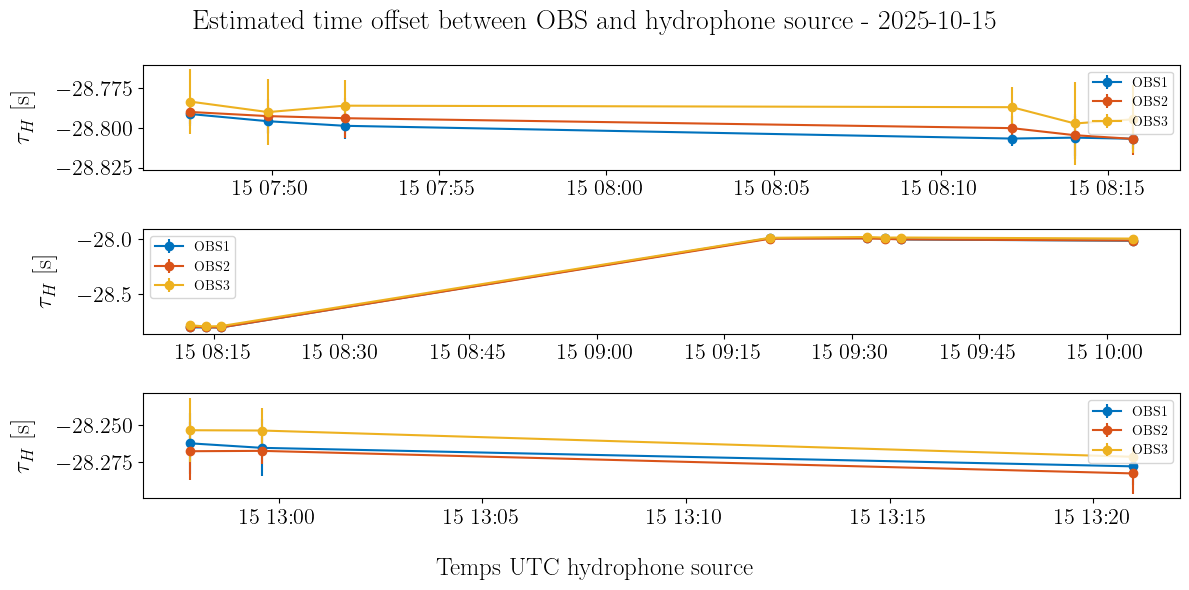

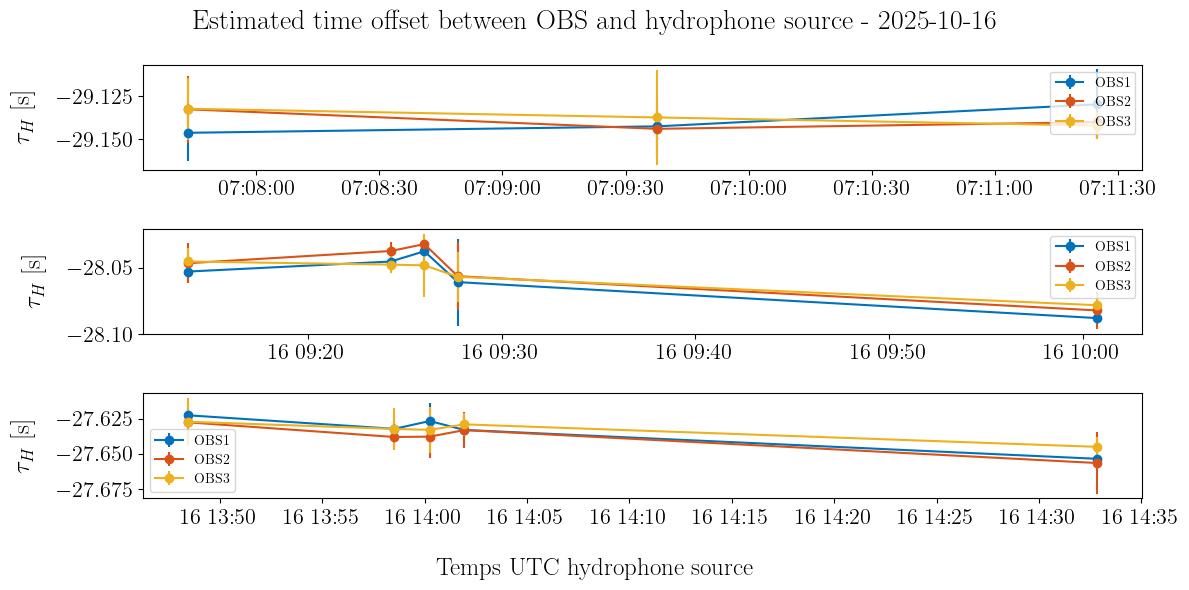

In [63]:
days = np.unique([d.date() for d in sequence_datetimes])

# fig, axs = plt.subplots(
#     days.size, 1, figsize=(12, 6)
# )

hour_lim_1 = 8
hour_lim_2 = 11

for day_idx, day in enumerate(days):
    # plt.figure(figsize=(12, 6))
    # ax = plt.gca()

    # ax = axs[day_idx] if days.size > 1 else axs
    fig, axs = plt.subplots(3, 1, figsize=(12, 6))

    day_mask = np.array([d.date() == day for d in sequence_datetimes])
    hour_lim_1_mask = np.array(
        [d.hour <= hour_lim_1 for d in sequence_datetimes[day_mask]]
    )
    hour_lim_2_mask = np.array(
        [
            (d.hour >= hour_lim_1) and (d.hour <= hour_lim_2)
            for d in sequence_datetimes[day_mask]
        ]
    )
    hour_lim_3_mask = np.array(
        [d.hour > hour_lim_2 for d in sequence_datetimes[day_mask]]
    )

    hour_masks = [hour_lim_1_mask, hour_lim_2_mask, hour_lim_3_mask]
    for i in range(3):
        axs[i].errorbar(
            np.array(sequence_datetimes)[day_mask][hour_masks[i]],
            np.array(obs1_mean_time_offsets)[day_mask][hour_masks[i]],
            yerr=3 * np.array(obs1_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS1",
            color=color(0),
        )

        axs[i].errorbar(
            np.array(sequence_datetimes)[day_mask][hour_masks[i]],
            np.array(obs2_mean_time_offsets)[day_mask][hour_masks[i]],
            yerr=3 * np.array(obs2_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS2",
            color=color(1),
        )

        axs[i].errorbar(
            np.array(sequence_datetimes)[day_mask][hour_masks[i]],
            np.array(obs3_mean_time_offsets)[day_mask][hour_masks[i]],
            yerr=3 * np.array(obs3_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS3",
            color=color(2),
        )

        # axs[i].set_xlabel("Temps UTC hydrophone source")
        axs[i].set_ylabel(r"$\tau_{H}$ [s]")
        axs[i].legend()

    fig.supxlabel("Temps UTC hydrophone source")
    fig.suptitle(f"Estimated time offset between OBS and hydrophone source - {day}")

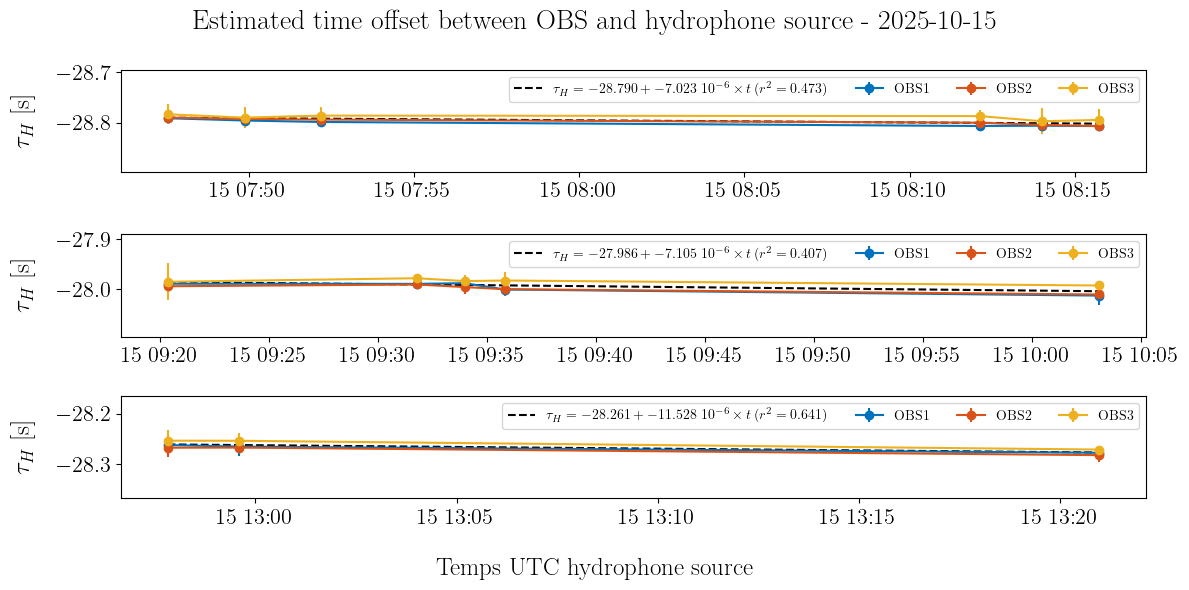

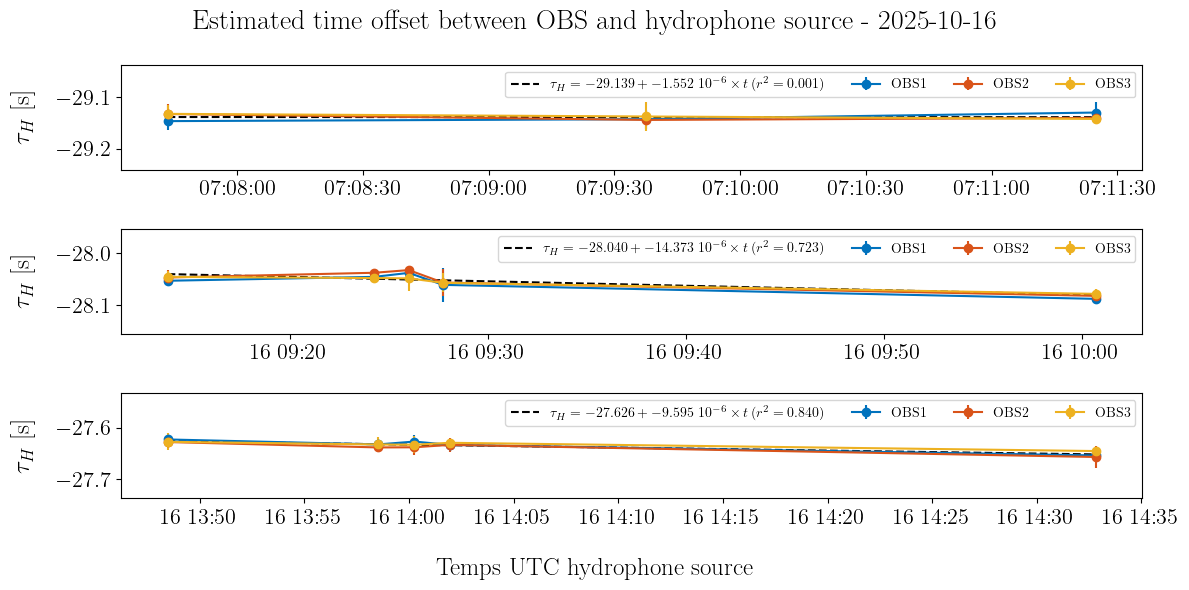

In [64]:
days = np.unique([d.date() for d in sequence_datetimes])

# fig, axs = plt.subplots(
#     days.size, 1, figsize=(12, 6)
# )

hour_lim_1 = 8.5
hour_lim_2 = 11 

for day_idx, day in enumerate(days):
    # plt.figure(figsize=(12, 6))
    # ax = plt.gca()


    # ax = axs[day_idx] if days.size > 1 else axs
    fig, axs = plt.subplots(
        3, 1, figsize=(12, 6)
    )

    day_mask = np.array([d.date() == day for d in sequence_datetimes])
    hour_lim_1_mask = np.array([d.hour <= hour_lim_1 for d in sequence_datetimes[day_mask]])
    hour_lim_2_mask = np.array(
        [
            (d.hour >= hour_lim_1) and (d.hour <= hour_lim_2)
            for d in sequence_datetimes[day_mask]
        ]
    )
    hour_lim_3_mask = np.array([d.hour > hour_lim_2 for d in sequence_datetimes[day_mask]])

    all_obs = np.hstack([obs1_mean_time_offsets, obs2_mean_time_offsets, obs3_mean_time_offsets])
    ax_min = np.min(all_obs)
    ax_max = np.max(all_obs)
    ax_range = ax_max - ax_min

    hour_masks = [hour_lim_1_mask, hour_lim_2_mask, hour_lim_3_mask]
    for i in range(3):
        time = np.array(sequence_datetimes)[day_mask][hour_masks[i]]
        obs1_masked = np.array(obs1_mean_time_offsets)[day_mask][hour_masks[i]]
        obs2_masked = np.array(obs2_mean_time_offsets)[day_mask][hour_masks[i]]
        obs3_masked = np.array(obs3_mean_time_offsets)[day_mask][hour_masks[i]]

        linear_time = time - time[0] # Linear time from start
        linear_time = [t.total_seconds() for t in linear_time]

        # 
        from scipy.stats import linregress 
        all_obs_masked = np.hstack([obs1_masked, obs2_masked, obs3_masked])
        all_linear_time = np.hstack([linear_time, linear_time, linear_time])
        slope, intercept, r, p, se = linregress(all_linear_time, all_obs_masked)

        # reg_time = np.array([time[0], time[-1]])
        reg_time = pd.date_range(time[0], time[-1], periods=100)
        lin_reg_time = np.array([t.total_seconds() for t in reg_time - reg_time[0]])
        y = intercept + slope * lin_reg_time
        axs[i].errorbar(
            time,
            obs1_masked,
            yerr=3*np.array(obs1_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS1",
            color=color(0),
        )

        axs[i].errorbar(
            time,
            obs2_masked,
            yerr=3*np.array(obs2_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS2",
            color=color(1),
        )

        axs[i].errorbar(
            time,
            obs3_masked,
            yerr=3*np.array(obs3_std_time_offsets)[day_mask][hour_masks[i]],
            fmt="o-",
            label="OBS3",
            color=color(2),
        )

        axs[i].plot(reg_time,
                    y,
                    linestyle="--",
                    color="k",
                    label=fr"$\tau_{{H}} = {{{intercept:.3f}}} + {{{slope*1e6:.3f}}}~10^{{-6}} \times t \,(r^2 = {{{r**2:.3f}}})$"
                    )

        # axs[i].set_xlabel("Temps UTC hydrophone source")
        axs[i].set_ylabel(r"$\tau_{H}$ [s]")
        axs[i].legend(ncols=4, loc="upper right")
        axs[i].set_ylim(np.mean(all_obs_masked)-ax_range/15, np.mean(all_obs_masked)+ax_range/15)

    fig.supxlabel("Temps UTC hydrophone source")
    fig.suptitle(f"Estimated time offset between OBS and hydrophone source - {day}")

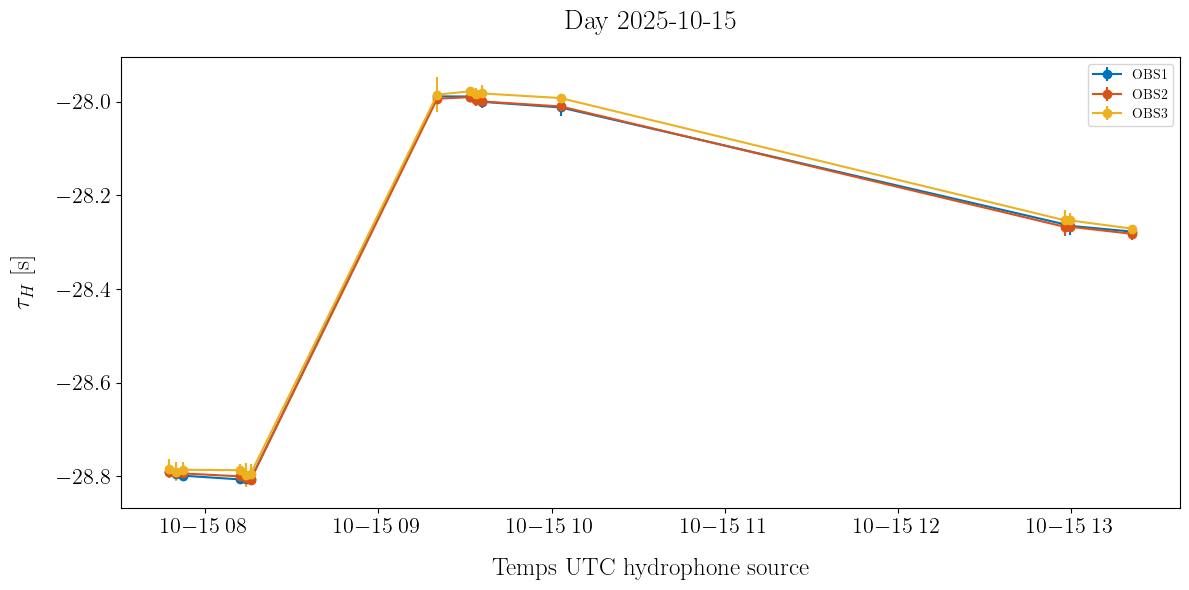

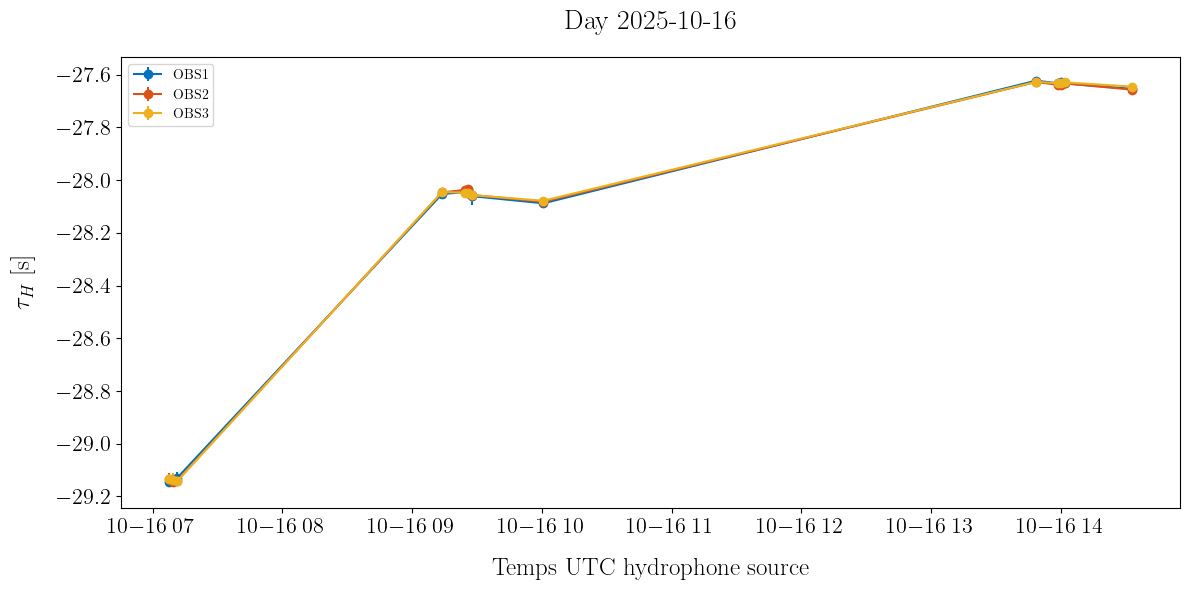

In [65]:

for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    plt.figure(figsize=(12, 6))
    ax = plt.gca()
    day_mask = np.array([d.date() == day for d in sequence_datetimes])
    ax.errorbar(
        np.array(sequence_datetimes)[day_mask],
        np.array(obs1_mean_time_offsets)[day_mask],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask],
        fmt="o-",
        label="OBS1",
        color=color(0),
    )
    ax.errorbar(
        np.array(sequence_datetimes)[day_mask],
        np.array(obs2_mean_time_offsets)[day_mask],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask],
        fmt="o-",
        label="OBS2",
        color=color(1),
    )
    ax.errorbar(
        np.array(sequence_datetimes)[day_mask],
        np.array(obs3_mean_time_offsets)[day_mask],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask],
        fmt="o-",
        label="OBS3",
        color=color(2),
    )
    ax.set_title(f"Day {day}")
    ax.set_xlabel("Temps UTC hydrophone source")
    ax.set_ylabel(r"$\tau_{H}$ [s]")
    ax.legend()

### Variations en fonction de la distance au capteur 

In [79]:
obs1_th_propagation_times = [
    time_diff[seq_id]["Theoretical propagation time OBS1"] for seq_id in sel_sequence_id
]
obs2_th_propagation_times = [
    time_diff[seq_id]["Theoretical propagation time OBS2"] for seq_id in sel_sequence_id
]
obs3_th_propagation_times = [
    time_diff[seq_id]["Theoretical propagation time OBS3"] for seq_id in sel_sequence_id
]

# Sort data by propagation time
sequence_datetimes = [time_diff[seq_id]["first_emission_datetime"] for seq_id in sel_sequence_id]
sequence_datetimes_obs1 = np.array(sequence_datetimes)[np.argsort(obs1_th_propagation_times)]
sequence_datetimes_obs2 = np.array(sequence_datetimes)[np.argsort(obs2_th_propagation_times)]
sequence_datetimes_obs3 = np.array(sequence_datetimes)[np.argsort(obs3_th_propagation_times)]
sel_sequence_id_obs1 = sel_sequence_id.copy()[np.argsort(obs1_th_propagation_times)
]
sel_sequence_id_obs2 = sel_sequence_id.copy()[np.argsort(obs2_th_propagation_times)
]
sel_sequence_id_obs3 = sel_sequence_id.copy()[np.argsort(obs3_th_propagation_times)
]
obs1_th_propagation_times = np.array(obs1_th_propagation_times)[
    np.argsort(obs1_th_propagation_times)
]
obs2_th_propagation_times = np.array(obs2_th_propagation_times)[
    np.argsort(obs2_th_propagation_times)
]
obs3_th_propagation_times = np.array(obs3_th_propagation_times)[
    np.argsort(obs3_th_propagation_times)
]

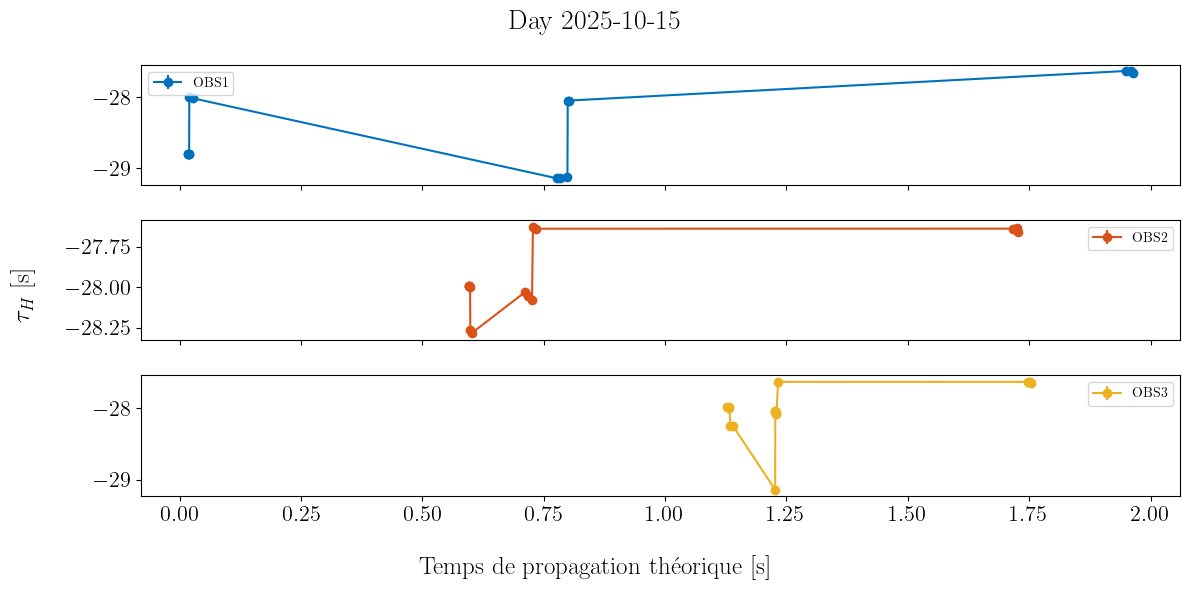

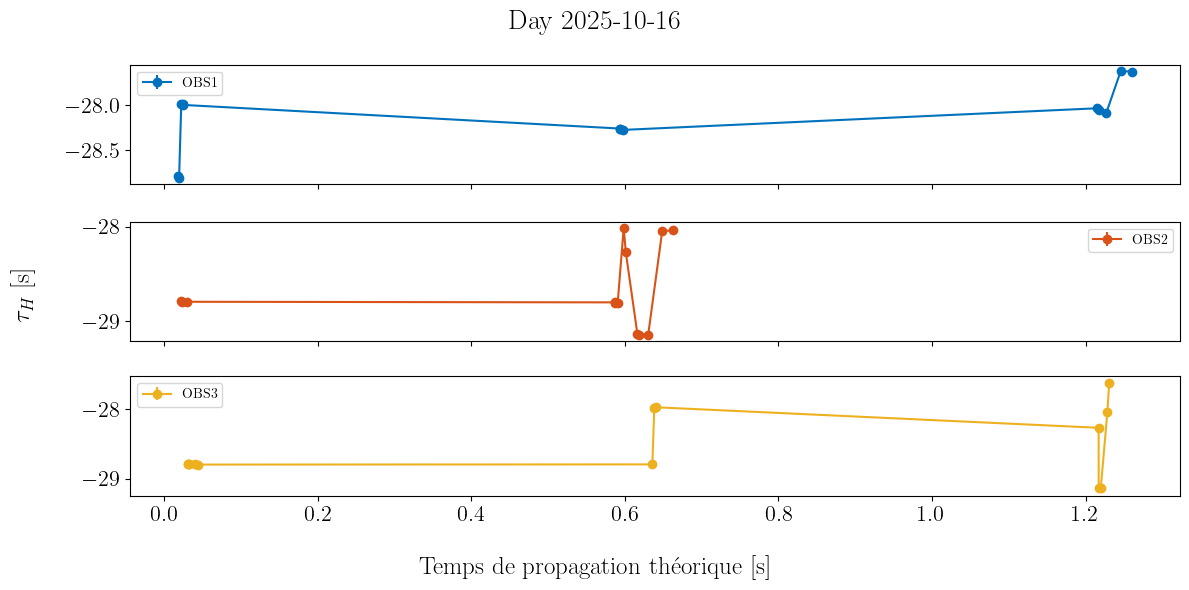

In [80]:
for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    day_mask_1 = np.array([d.date() == day for d in sequence_datetimes_obs1])
    day_mask_2 = np.array([d.date() == day for d in sequence_datetimes_obs2])
    day_mask_3 = np.array([d.date() == day for d in sequence_datetimes_obs3])

    axs[0].errorbar(
        obs1_th_propagation_times[day_mask_1],
        np.array(obs1_mean_time_offsets)[day_mask_1],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask_1],
        fmt="o-",
        label="OBS1",
        color=color(0),
    )
    axs[1].errorbar(
        obs2_th_propagation_times[day_mask_2],
        np.array(obs2_mean_time_offsets)[day_mask_2],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask_2],
        fmt="o-",
        label="OBS2",
        color=color(1),
    )
    axs[2].errorbar(
        obs3_th_propagation_times[day_mask_3],
        np.array(obs3_mean_time_offsets)[day_mask_3],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask_3],
        fmt="o-",
        label="OBS3",
        color=color(2),
    )
    fig.suptitle(f"Day {day}")
    fig.supxlabel("Temps de propagation théorique [s]")
    fig.supylabel(r"$\tau_{H}$ [s]")
    axs[0].legend()
    axs[1].legend()
    axs[2].legend()

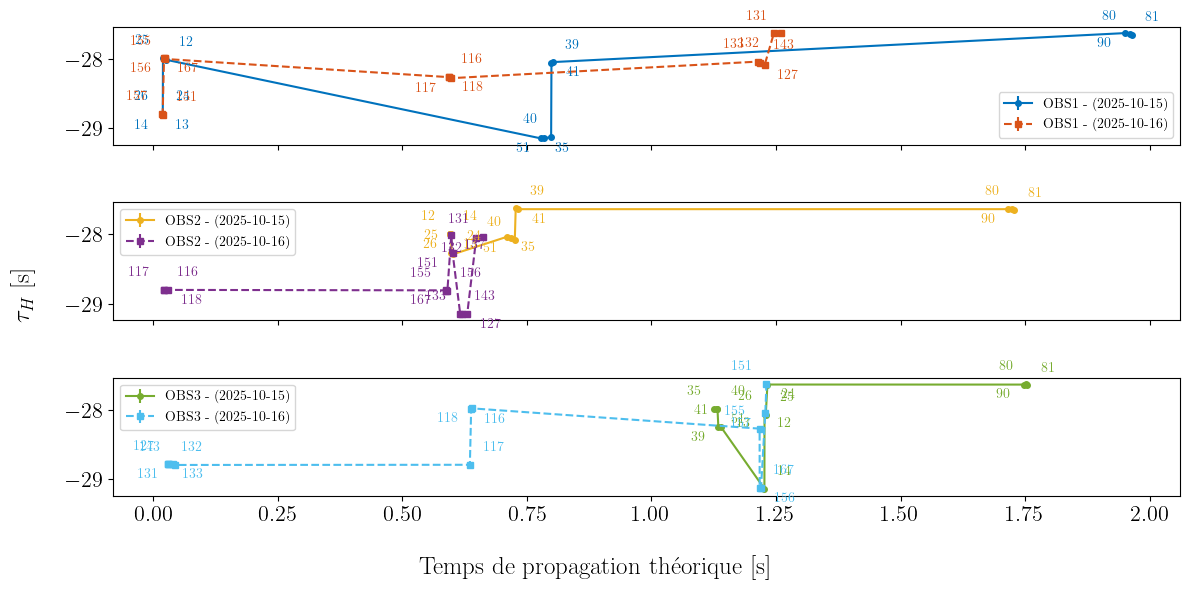

In [88]:
fig, axs = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
formats = ["o-", "s--", "x:"]
for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    day_mask_1 = np.array([d.date() == day for d in sequence_datetimes_obs1])
    day_mask_2 = np.array([d.date() == day for d in sequence_datetimes_obs2])
    day_mask_3 = np.array([d.date() == day for d in sequence_datetimes_obs3])

    axs[0].errorbar(
        obs1_th_propagation_times[day_mask_1],
        np.array(obs1_mean_time_offsets)[day_mask_1],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask_1],
        fmt=formats[day_idx],
        label=f"OBS1 - ({day})",
        color=color(0 + day_idx),
        markersize=4,
    )

    axs[1].errorbar(
        obs2_th_propagation_times[day_mask_2],
        np.array(obs2_mean_time_offsets)[day_mask_2],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask_2],
        fmt=formats[day_idx],
        label=f"OBS2 - ({day})",
        color=color(2 + day_idx),
        markersize=4,
    )
    axs[2].errorbar(
        obs3_th_propagation_times[day_mask_3],
        np.array(obs3_mean_time_offsets)[day_mask_3],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask_3],
        fmt=formats[day_idx],
        label=f"OBS3 - ({day})",
        color=color(4 + day_idx),
        markersize=4,
    )

    # Annotate each data point with the corresponding sequence id
    sel_sequence_id_obs1_day = np.array(sel_sequence_id_obs1)[day_mask_1]
    sel_sequence_id_obs2_day = np.array(sel_sequence_id_obs2)[day_mask_2]
    sel_sequence_id_obs3_day = np.array(sel_sequence_id_obs3)[day_mask_3]
    day_masks = [day_mask_1, day_mask_2, day_mask_3]
    for i_obs in [1, 2, 3]:
        if i_obs == 1:
            sel_sequence_id_obs = sel_sequence_id_obs1_day
            th_propa_obs = obs1_th_propagation_times
            time_offset_obs = obs1_mean_time_offsets 
        elif i_obs == 2:
            sel_sequence_id_obs = sel_sequence_id_obs2_day
            th_propa_obs = obs2_th_propagation_times
            time_offset_obs = obs2_mean_time_offsets
        else:
            sel_sequence_id_obs = sel_sequence_id_obs3_day
            th_propa_obs = obs3_th_propagation_times
            time_offset_obs = obs3_mean_time_offsets

        j_lab = 0
        for i, seq_id in enumerate(sel_sequence_id_obs):
            # print(
            #     f"OBS{i_obs} - Annotating sequence {seq_id} -> th_propa: {th_propa_obs[day_mask][i]}"
            # )
            # Alternate the position of the labels to avoid overlap
            ha = "right" if j_lab % 4 in [0, 3] else "left"
            x_offset = -10 if j_lab % 4 in [0, 3] else 10
            y_offset = 10 if j_lab % 4 in [0, 1] else -10
            axs[i_obs - 1].annotate(
                seq_id,
                (
                    th_propa_obs[day_masks[i_obs - 1]][i],
                    np.array(time_offset_obs)[day_masks[i_obs - 1]][i],
                ),
                textcoords="offset points",
                xytext=(x_offset, y_offset),
                ha=ha,
                fontsize=10,
                color=color((i_obs - 1) * 2 + day_idx),
                fontweight="bold",
            )
            j_lab += 1

# fig.suptitle(f"Day {day}")
fig.supxlabel("Temps de propagation théorique [s]")
fig.supylabel(r"$\tau_{H}$ [s]")
axs[0].legend()
axs[1].legend()
axs[2].legend()
# axs[0].set_xscale("log")

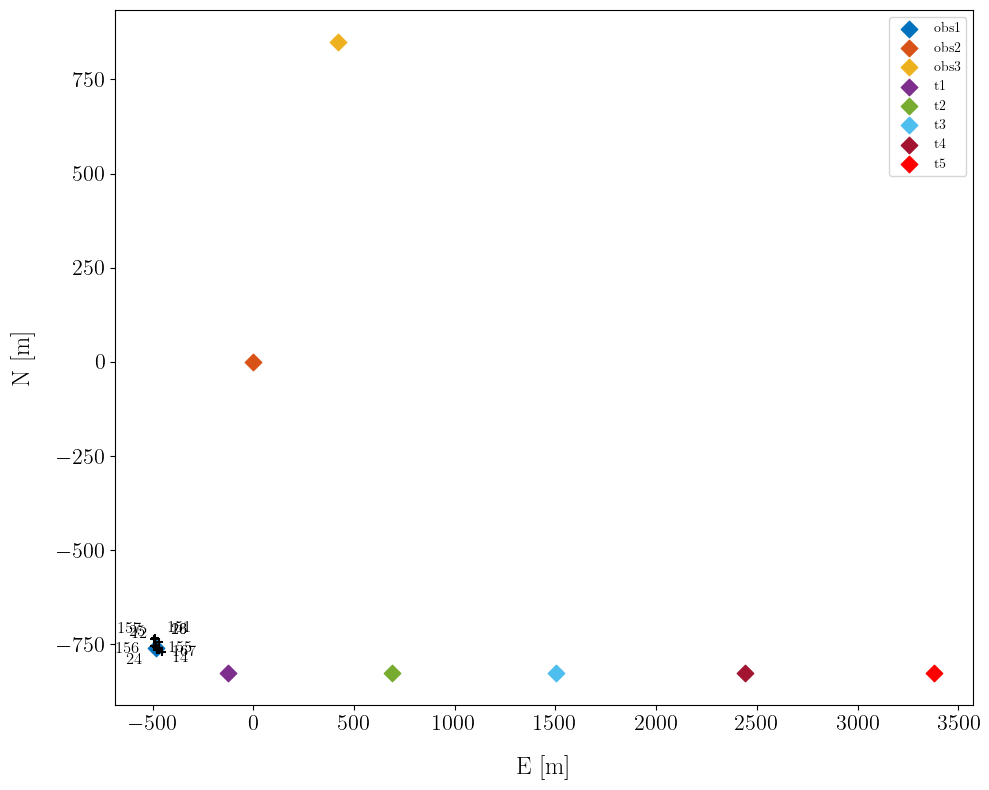

In [93]:
# Tracer des positions d'émission et des positions des OBS sur une carte
sel_sequence_id_to_analyse = [str(seq_id) for seq_id in [12, 13, 14, 24, 25, 26, 155, 156, 157, 151, 167]]
# Plot
plt.figure(figsize=(10, 8))
for i, seq_id in enumerate(sel_sequence_id_to_analyse):
    df_sequence = df_processed.loc[df_processed["Sequence_id"] == seq_id]
    # print(f"Sequence {seq_id}:")
    # print(df_sequence.head(2))
    # Get propagation time for OBS1
    # time_diff[seq_id]["Theoretical propagation time OBS1"]
    # print(f"Sequence {seq_id}: theoretical propagation time OBS1 = {df_sequence['Theoretical propagation time OBS1']} s")


    plt.scatter(
        df_sequence["Emission interpolated E GPS"].iloc[0],
        df_sequence["Emission interpolated N GPS"].iloc[0],
        marker="+",
        color="k",
        # "s",
        # label="Sequence emission pos",
    )
    # Annotate with sequence id
    # Alternate the position of the labels to avoid overlap
    ha = "right" if i % 4 in [0, 3] else "left"
    x_offset = -10 if i % 4 in [0, 3] else 10
    y_offset = 10 if i % 4 in [0, 1] else -10
    plt.annotate(
        seq_id,
        (
            df_sequence["Emission interpolated E GPS"].iloc[0],
            df_sequence["Emission interpolated N GPS"].iloc[0],
        ),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha=ha,
        fontsize=12,
    )


plt.xlabel("E [m]")
plt.ylabel("N [m]")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for ik, k in enumerate(keys):
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    plt.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=0,
        color=color(ik),
        s=70,
    )


plt.legend()

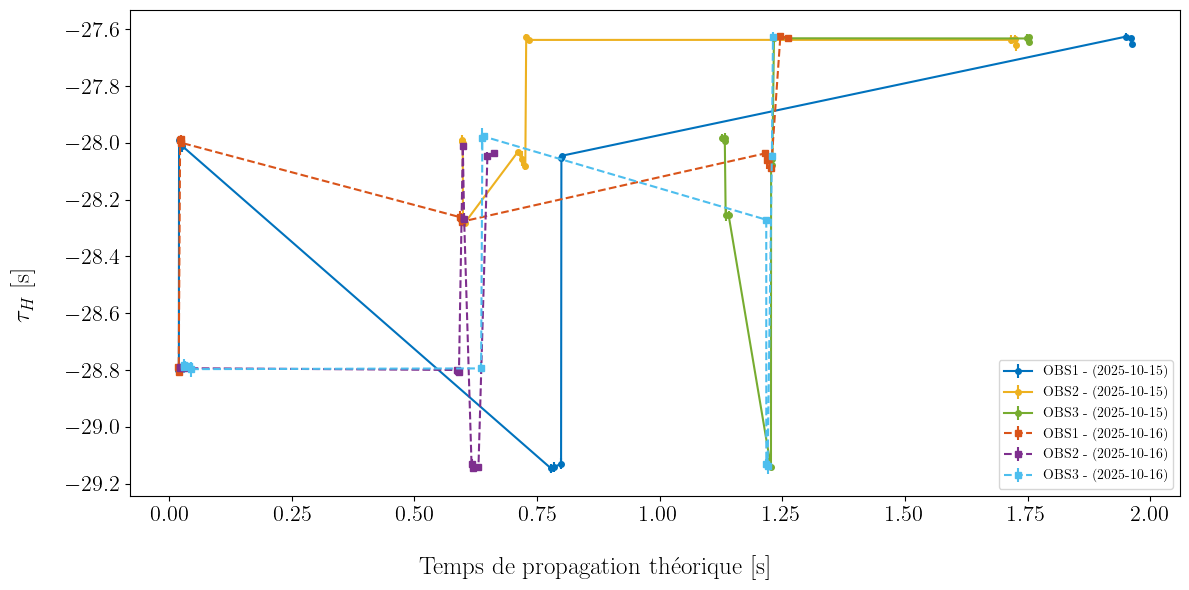

In [89]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=True)
formats = ["o-", "s--", "x:"]
for day_idx, day in enumerate(days):
    # ax = axs[day_idx] if days.size > 1 else axs
    day_mask_1 = np.array([d.date() == day for d in sequence_datetimes_obs1])
    day_mask_2 = np.array([d.date() == day for d in sequence_datetimes_obs2])
    day_mask_3 = np.array([d.date() == day for d in sequence_datetimes_obs3])

    ax.errorbar(
        obs1_th_propagation_times[day_mask_1],
        np.array(obs1_mean_time_offsets)[day_mask_1],
        yerr=3 * np.array(obs1_std_time_offsets)[day_mask_1],
        fmt=formats[day_idx],
        label=f"OBS1 - ({day})",
        color=color(0 + day_idx),
        markersize=4,
    )

    ax.errorbar(
        obs2_th_propagation_times[day_mask_2],
        np.array(obs2_mean_time_offsets)[day_mask_2],
        yerr=3 * np.array(obs2_std_time_offsets)[day_mask_2],
        fmt=formats[day_idx],
        label=f"OBS2 - ({day})",
        color=color(2 + day_idx),
        markersize=4,
    )
    ax.errorbar(
        obs3_th_propagation_times[day_mask_3],
        np.array(obs3_mean_time_offsets)[day_mask_3],
        yerr=3 * np.array(obs3_std_time_offsets)[day_mask_3],
        fmt=formats[day_idx],
        label=f"OBS3 - ({day})",
        color=color(4 + day_idx),
        markersize=4,
    )

# fig.suptitle(f"Day {day}")
fig.supxlabel("Temps de propagation théorique [s]")
fig.supylabel(r"$\tau_{H}$ [s]")
ax.legend()

#### Remarques 


In [72]:
df_processed.head(10)
# processed_data

,Emission datetime,Sequence_id,Point,Source,Longueur filée (m),Hydro distance (m),Signal,Frequency min (Hz),Frequency max (Hz),Duration (s),...,Arrival datetime OBS2,Theoretical propagation time OBS2,Measured propagation time OBS2,PSNR OBS2,Valid detection OBS2,Arrival datetime OBS3,Theoretical propagation time OBS3,Measured propagation time OBS3,PSNR OBS3,Valid detection OBS3
0,2025-10-15 07:49:53.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:50:22.616500,0.596752,29.391844,45.564245,True,2025-10-15 07:50:23.233500,1.227054,30.008844,21.704954,True
1,2025-10-15 07:50:03.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:50:32.607500,0.596498,29.382844,51.398918,True,2025-10-15 07:50:33.243000,1.226729,30.018344,25.356718,True
2,2025-10-15 07:50:13.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:50:42.613500,0.596248,29.388844,72.740276,True,2025-10-15 07:50:43.232500,1.226405,30.007844,29.161804,True
3,2025-10-15 07:50:23.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:50:52.613000,0.595755,29.388344,63.149165,True,2025-10-15 07:50:53.242000,1.225842,30.017344,27.721877,True
4,2025-10-15 07:50:33.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:51:02.605500,0.594827,29.380844,64.111239,True,2025-10-15 07:51:03.241500,1.224877,30.016844,28.560530,True
5,2025-10-15 07:50:43.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:51:12.612000,0.594065,29.387344,90.079505,True,2025-10-15 07:51:13.226000,1.224129,30.001344,22.343997,True
6,2025-10-15 07:50:53.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:51:22.612500,0.593303,29.387844,80.332921,True,2025-10-15 07:51:23.243000,1.223382,30.018344,36.364819,True
7,2025-10-15 07:51:03.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:51:32.613000,0.592542,29.388344,75.528818,True,2025-10-15 07:51:33.242500,1.222634,30.017844,43.205348,True
8,2025-10-15 07:51:13.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:51:42.608500,0.592047,29.383844,70.913060,True,2025-10-15 07:51:43.244500,1.222169,30.019844,32.158079,True
9,2025-10-15 07:51:23.224656250,13,1,fixed,2,1.3,chirp,80.0,1000.0,5.0,...,2025-10-15 07:51:52.615000,0.592361,29.390344,106.168598,True,2025-10-15 07:51:53.244500,1.222538,30.019844,36.360493,True


In [73]:
# obs_id = 1  # Correspondance OBS 1 = OBS 4, OBS 2 = OBS 5, OBS 3 = OBS 6

# verbose = False
# savefig = True
# plot = True
# plot_zoom = False

# # Convention Gen_Axes_D_V4 (Cf ELOBSBin2Wav.py)
# channels_order = {
#     "Z": 0,
#     "X": 1,
#     "Y": 2,
#     "H": 3,
# }
# used_channel = "H"

# # TODO : check to remove this or to moove it earlier
# t_hydro_source_offset = 30  # seconds

# # Window parameters
# pre_reception_time = 5.0  # seconds before reception to include in the window
# post_reception_time = 5.0  # seconds after reception to include in the window

# # Correct window for hydrophone to source offset
# pre_reception_time -= t_hydro_source_offset
# post_reception_time += t_hydro_source_offset

# origin_keys = df_sel.columns.to_list()
# processed_keys = origin_keys
# processed_data = {key: [] for key in processed_keys}


# # List available wav files for each OBS (to avoid reloading them for each sequence)
# wav_start_times_dict = {}
# start_datetime_arr_dict = {}
# for obs_id in [1, 2, 3]:
#     wav_start_times, start_datetime_arr = get_available_wav_files(obs_id)
#     wav_start_times_dict[obs_id] = wav_start_times
#     start_datetime_arr_dict[obs_id] = start_datetime_arr

# sel_sequence_id = df_sel["Sequence_id"].unique()
# sel_sequence_id = sel_sequence_id[
#     :5
# ]  # Reduce the number of sequence to process for debugging / test
# for seq_id in sel_sequence_id:
#     df_sequence = df_sel.loc[df_sel["Sequence_id"] == seq_id]

#     new_data = {}
#     # Lood over receivers
#     for obs_id in [1, 2, 3]:

#         # Get available wav files for the selected OBS
#         wav_start_times = wav_start_times_dict[obs_id]
#         start_datetime_arr = start_datetime_arr_dict[obs_id]

#         ### Load signal of interest ###
#         # Get all theoretical arrival time
#         emissions_datetime = []
#         th_arrivals_datetime = []
#         th_propagation_delay = []
#         th_arrivals_seconds_from_start = []
#         for emission_id in range(df_sequence.shape[0]):
#             emission_i = df_sequence.iloc[emission_id]
#             emission_i_datetime = emission_i["Emission datetime"].to_pydatetime(
#                 warn=False
#             )
#             emissions_datetime.append(emission_i_datetime)

#             if emission_id == 0:  # First emission in sequence
#                 # Find the corresponding wav file (for now we assume that the sequence fits in a single wav file)
#                 wav_fpath, wav_start_datetime = get_wav_file_for_emission(
#                     emission_datetime=emission_i_datetime,
#                     start_datetime_arr=start_datetime_arr,
#                     wav_start_times=wav_start_times,
#                 )
#                 print(f"Corresponding wav file (OBS{obs_id}): {wav_fpath}")

#             # Emission position
#             emission_i_pos = [
#                 emission_i["Emission interpolated N GPS"],
#                 emission_i["Emission interpolated U GPS"],
#                 emission_i["Emission interpolated E GPS"],
#             ]
#             # Theoretical time of arrival
#             emission_i_reception_datetime, tr_i, prop_time_i = get_tr_apriori(
#                 emission_i_pos,
#                 wav_start_datetime,
#                 emission_i_datetime,
#                 obs_id,
#             )
#             th_propagation_delay.append(prop_time_i)
#             th_arrivals_datetime.append(emission_i_reception_datetime)
#             th_arrivals_seconds_from_start.append(tr_i)

#         # Convert to numpy arrays
#         th_propagation_delay = np.array(th_propagation_delay)
#         th_arrivals_datetime = np.array(th_arrivals_datetime)
#         th_arrivals_seconds_from_start = np.array(th_arrivals_seconds_from_start)

#         # First emission in the sequence
#         first_emission_in_sequence_datetime = emissions_datetime[0]
#         first_emission_reception_datetime = th_arrivals_datetime[0]
#         tr_first = th_arrivals_seconds_from_start[0]
#         # Last emission in sequence
#         last_emission_in_sequence_datetime = emissions_datetime[-1]
#         last_emission_reception_datetime = th_arrivals_datetime[-1]
#         tr_last = th_arrivals_seconds_from_start[-1]
#         print(
#             f"Processing sequence {seq_id} from {first_emission_in_sequence_datetime} to {last_emission_in_sequence_datetime}"
#         )

#         # Load the wav file
#         print("Loading wav file...")
#         # Read the wav file
#         signal, fs = sf.read(wav_fpath)
#         # Select the channel
#         signal = signal[:, channels_order[used_channel]]
#         # Remove mean
#         signal = signal - np.mean(signal)

#         # Compute source position considering the offset for the current emission   (Source, Longueur filée)
#         # TODO : implement position correction if needed

#         # Select the time window of interest for current sequence (all emissions in the sequence + pre/post times)
#         t_start_win = tr_first - pre_reception_time
#         t_end_win = tr_last + post_reception_time

#         # Convert in samples
#         n_samp_start_win = int(t_start_win * fs)
#         n_samp_end_win = int(t_end_win * fs)
#         # Slice signal
#         signal_win = signal[n_samp_start_win:n_samp_end_win]
#         wav_end_datetime = wav_start_datetime + pd.Timedelta(
#             signal.shape[0] * 1 / fs, "s"
#         )
#         t_dt = pd.date_range(
#             wav_start_datetime, wav_end_datetime, freq=f"{1/fs}s", inclusive="left"
#         )
#         t_win = t_dt[n_samp_start_win:n_samp_end_win]
#         print(f"Original signal from {wav_start_datetime} to {wav_end_datetime}")
#         print(f"Selected window from {t_win[0]} to {t_win[-1]}")

#         ### Get arrivals ###
#         peaks_idx, peak_times, t_arrivals, sig_mf, signal_params = get_arrivals(
#             signal_win,
#             t_win,
#             df_sequence,
#             fs,
#             verbose=verbose,
#         )

#         ### Plot arrivals ###
#         if plot:
#             sequence_info = {
#                 "seq_id": seq_id,
#                 "obs_id": obs_id,
#                 "vc_carte": vc_carte,
#                 "signal_type": signal_type,
#                 "emission_type": emission_type,
#             }
#             nperseg = 64
#             noverlap = int(nperseg * 0.5)

#             plot_arrivals_detection(
#                 t_win=t_win,
#                 signal_win=signal_win,
#                 sig_mf=sig_mf,
#                 t_arrivals=t_arrivals,
#                 peaks_idx=peaks_idx,
#                 peak_times=peak_times,
#                 first_emission_reception_datetime=first_emission_reception_datetime,
#                 last_emission_reception_datetime=last_emission_reception_datetime,
#                 sequence_info=sequence_info,
#                 signal_params=signal_params,
#                 t_hydro_source_offset=t_hydro_source_offset,
#                 save=savefig,
#                 fs=fs,
#                 nperseg=nperseg,
#                 noverlap=noverlap,
#                 first_emission_in_sequence_datetime=None,
#                 last_emission_in_sequence_datetime=None,
#                 verbose=verbose,
#                 plot_zoom=plot_zoom,
#             )

#             plt.close("all")

#         ### Compute quality metrics for the detected arrivals ###
#         # Derive peak signal to noise ratio (PSNR) on matched filtered signal
#         psnr_arrivals = detected_arrivals_psnr(
#             sig_mf, peaks_idx, signal_params, fs, plot=False
#         )
#         # print(psnr_arrivals)

#         # Convert t_arrivals into datetime.datetime
#         t_arrivals_dt = np.array(
#             [t_arr.to_pydatetime(warn=False) for t_arr in t_arrivals]
#         )

#         valid_detection = np.zeros_like(emissions_datetime, dtype=bool)
#         # Pad in case not all peaks are detected
#         psnr_arrivals_full = np.full_like(emissions_datetime, np.nan, dtype=float)
#         t_arrivals_full = np.full_like(emissions_datetime, pd.NaT)
#         t_arrivals_dt_full = np.full_like(emissions_datetime, pd.NaT)

#         # Associate arrivals to closest theoretical arrival
#         th_arrivals_datetime_copy = th_arrivals_datetime.copy()
#         for i_t_arr, t_arr_dt in enumerate(t_arrivals_dt):
#             # Find closest
#             closest_th_arr_idx = np.argmin(np.abs(th_arrivals_datetime_copy - t_arr_dt))
#             # Remove this theoretical arrival from the copy to avoid double matching
#             th_arrivals_datetime_copy = np.delete(
#                 th_arrivals_datetime_copy, closest_th_arr_idx
#             )
#             # Replace in padded arrays
#             t_arrivals_dt_full[closest_th_arr_idx] = t_arr_dt
#             t_arrivals_full[closest_th_arr_idx] = t_arrivals[i_t_arr]
#             psnr_arrivals_full[closest_th_arr_idx] = psnr_arrivals[i_t_arr]

#             # Set valid_detection flag to true
#             valid_detection[closest_th_arr_idx] = True

#         # Derive propagation time
#         meas_propagation_delay = t_arrivals_dt_full - np.array(emissions_datetime)
#         meas_propagation_delay = np.array(
#             [t.total_seconds() for t in meas_propagation_delay]
#         )

#         # if int(seq_id) == 100:
#         #     print("Debug seq 100")

#         # Add new data for current obs
#         new_data[f"Arrival datetime OBS{obs_id}"] = list(t_arrivals_full)
#         new_data[f"Theoretical propagation time OBS{obs_id}"] = list(
#             th_propagation_delay
#         )
#         new_data[f"Measured propagation time OBS{obs_id}"] = list(
#             meas_propagation_delay
#         )
#         new_data[f"PSNR OBS{obs_id}"] = list(psnr_arrivals)
#         new_data[f"Valid detection {obs_id}"] = list(valid_detection)

#     # Copy data for processed emissions
#     for key in origin_keys:
#         processed_data[key].extend(df_sequence[key].values)
#     for key in new_data:
#         if key in processed_data.keys():
#             processed_data[key].extend(new_data[key])
#         else:
#             processed_data[key] = new_data[key]

#     # processed_data[""]

# for key in processed_data.keys():
#     print(len(processed_data[key]))
#     if len(processed_data[key]) != 60:
#         print(key)
# # Convert to dataframe
# df_processed = pd.DataFrame(processed_data)

In [74]:
# # Loop over selected emissions
# idx = df_sel.index.tolist()[:5]   # Just take first 5 for testing

# for idx in idx: 
#     row = df_sel.loc[idx]
#     # print(row)

#     # Compute source position considering the offset for the current emission   (Source, Longueur filée)

#     # Find the corresponding wav file
#     emission_datetime = row["Emission datetime"].to_pydatetime()
#     wav_fpath, wav_start_datetime = get_wav_file_for_emission(emission_datetime)
#     # print(f"Emission datetime : {emission_datetime}")
#     # print(f"Corresponding wav file: {wav_fpath}")

#     # Load the wav file
#     print("Loading wav file...")
#     # sf_info = sf.info(wav_fpath)
#     # Read the wav file
#     signal, fs = sf.read(wav_fpath)
#     # Select the channel
#     signal = signal[:, channels_order[used_channel]]
#     # Select the time window corresponding to the emission
#     emission_pos = [
#         row["Emission interpolated E GPS"],
#         row["Emission interpolated N GPS"],
#         row["Emission interpolated U GPS"],
#     ]
#     # Tr : time in seconds from recording start corresponding to expected reception
#     reception_datetime, tr = get_tr_apriori(
#         emission_pos, wav_start_datetime, emission_datetime, obs_id
#     )
#     t_start_win = tr - pre_reception_time
#     t_end_win = tr + post_reception_time
#     # Convert in samples
#     n_samp_start_win = int(t_start_win * fs)
#     n_samp_end_win = int(t_end_win * fs)
#     # Slice signal
#     signal_win = signal[n_samp_start_win:n_samp_end_win]
#     wav_end_datetime = wav_start_datetime + pd.Timedelta(signal.shape[0] * 1/fs,"s")
#     t_dt = pd.date_range(wav_start_datetime, wav_end_datetime, freq=f"{1/fs}s", inclusive="left")
#     t_win = t_dt[n_samp_start_win:n_samp_end_win]

    # Apply match filtering






#     print("Applying match filtering...")
#     # Extract signal parameters
#     f0 = row["Frequency min (Hz)"]
#     f1 = row["Frequency max (Hz)"]
#     chirp_T = row["Duration (s)"]
#     lags, sig_mf = apply_match_filter(signal_win, fs, f0, f1, chirp_T)

#     # Compute spectrogram for visualization
#     nperseg = 64
#     noverlap = int(nperseg * 0.5)
#     ff, tt, Sxx = sp.stft(
#         signal_win,
#         fs=fs,
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling="psd",
#     )
#     tt_datetime = pd.date_range(
#         t_win[0], t_win[0] + pd.Timedelta(tt[-1], "s"), freq=f"{tt[1]-tt[0]}s", inclusive="both"
#     )

#     print("Plotting results...")
#     fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
#     # Plot raw signal
#     axs[0].plot(t_win, signal_win)
#     # axs[0].set_xlabel("Temps UTC")
#     axs[0].set_ylabel("s")

#     # Plot matched filtered signal
#     axs[1].plot(t_win, sig_mf)
#     # axs[1].set_xlabel("Temps UTC")
#     axs[1].set_ylabel(r"$s_{mf}$")

#     im = axs[2].pcolormesh(tt_datetime, ff, 10 * np.log10(np.abs(Sxx)), cmap="jet")
#     # fig.colorbar(im, cax=axs[2], label=r"Pa$^2$ / Hz in dB")
#     axs[2].set_ylabel("Frequency [Hz]")
#     # axs[2].set_xlabel("Temps [s]")


#     fig.supxlabel("Temps UTC")
#     # fig.supylabel("Signal")
#     plt.show()
#     # signal =